<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/MetricaClasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# Sistema de detección de fraude bancario
# Evaluación de métricas de clasificación
# ============================================

# 1. Importar librerías

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ============================================
# 2. Crear un dataset
# monto, hora y si fue fraude
# 1 = Fraude
# 0 = Transacción normal
# ============================================

data = {
    "monto":[50,1200,35,5000,70,8000,45,6500,90,7200],
    "hora":[9,2,14,1,10,3,16,0,11,4],
    "fraude":[0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

print(df)


   monto  hora  fraude
0     50     9       0
1   1200     2       1
2     35    14       0
3   5000     1       1
4     70    10       0
5   8000     3       1
6     45    16       0
7   6500     0       1
8     90    11       0
9   7200     4       1


In [3]:
# ============================================
# 3. Variables independientes y dependiente
# ============================================

X = df[["monto","hora"]]
y = df["fraude"]

In [4]:
# ============================================
# 4. Dividir entrenamiento y prueba
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [5]:
# ============================================
# 5. Entrenar modelo
# ============================================

modelo = LogisticRegression()

modelo.fit(X_train,y_train)

LogisticRegression()

In [6]:
# ============================================
# 6. Predicciones
# ============================================

y_pred = modelo.predict(X_test)


In [7]:
# ============================================
# 7. Métricas
# ============================================

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Accuracy: 0.6666666666666666
Precision: 1.0
Recall: 0.5
F1 Score: 0.6666666666666666


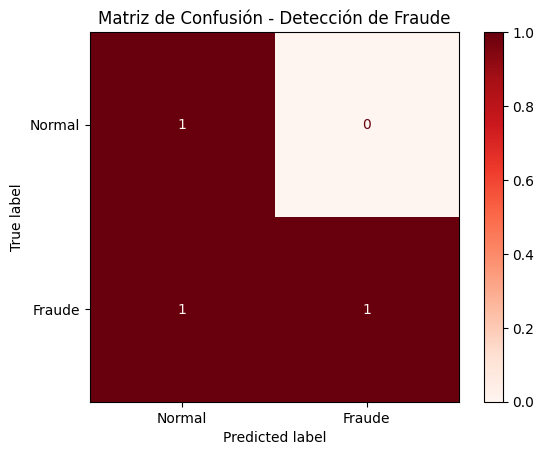

In [8]:
# ============================================
# 8. Matriz de confusión
# ============================================

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal","Fraude"]
)

disp.plot(cmap=plt.cm.Reds)

plt.title("Matriz de Confusión - Detección de Fraude")

plt.show()

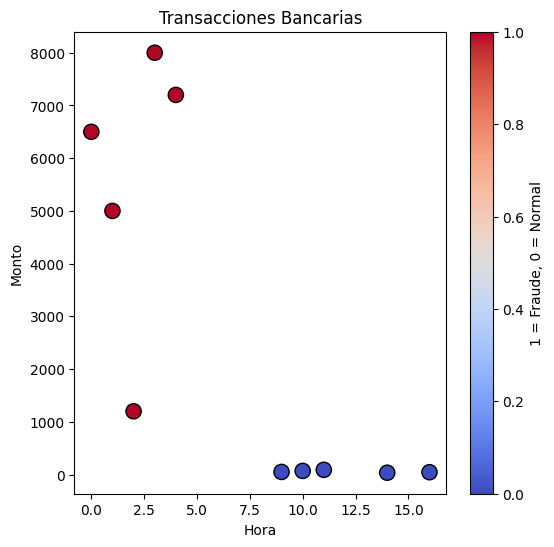

In [9]:
# ============================================
# 9. Visualización
# ============================================

plt.figure(figsize=(6,6))

plt.scatter(
    df["hora"],
    df["monto"],
    c=df["fraude"],
    cmap="coolwarm",
    s=120,
    edgecolors="black"
)

plt.xlabel("Hora")
plt.ylabel("Monto")
plt.title("Transacciones Bancarias")
plt.colorbar(label="1 = Fraude, 0 = Normal")

plt.show()